In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Подготовка данных

In [3]:
df = pd.read_csv('../data/GlobalTemperatures/GlobalLandTemperaturesByCountry.csv')

In [4]:
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


In [5]:
belarus_df = df[df['Country'] == 'Belarus'].copy()
belarus_df.drop(columns=['Country', 'AverageTemperatureUncertainty'], inplace=True)

In [6]:
belarus_df['dt'] = pd.to_datetime(belarus_df['dt'])
belarus_df.set_index('dt', inplace=True)
belarus_df.head()

,AverageTemperature
dt,
1743-11-01,0.767
1743-12-01,NaN
1744-01-01,NaN
1744-02-01,NaN
1744-03-01,NaN


In [7]:
min_date = belarus_df.index.min()
max_date = belarus_df.index.max()

print(f"Минимальная дата: {min_date.date()}")
print(f"Максимальная дата: {max_date.date()}")

Минимальная дата: 1743-11-01
Максимальная дата: 2013-09-01


## Работа с пропусками в данных

In [9]:
belarus_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3239 entries, 1743-11-01 to 2013-09-01
Data columns (total 1 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   AverageTemperature  3166 non-null   float64
dtypes: float64(1)
memory usage: 50.6 KB


Изучаем пропуски:

In [11]:
missing = belarus_df.isnull().any(axis=1)
years_with_missing = belarus_df.index[missing].year
missing_per_year = pd.Series(years_with_missing).value_counts().sort_index()
for year, count in missing_per_year.items():
    print(f"{year}: {count}")

1743: 1
1744: 4
1745: 8
1746: 12
1747: 12
1748: 12
1749: 12
1750: 1
1751: 4
1752: 6
2013: 1


Большинство пропусков в бородатых годах и один пропуск в 2013, его изучим подробнее.

In [13]:
belarus_df[missing & (belarus_df.index.year == 2013)]

,AverageTemperature
dt,
2013-09-01,NaN


Получается у нас пропуск в последней дате и в 1750-ых годах. В качестве борьбы с ними просто удалим последнюю запись и оставим записи с 1753 года.

In [15]:
belarus_df = belarus_df[belarus_df.index.year >= 1753]
belarus_df = belarus_df.iloc[:-1]

In [16]:
total_missing = belarus_df.isnull().sum().sum()
print(f"Общее количество пропусков: {total_missing}")

Общее количество пропусков: 0


## Работа с выбросами

In [18]:
belarus_df.describe()

,AverageTemperature
count,3128.000000
mean,5.831910
std,9.182169
min,-16.527000
25%,-2.232000
50%,5.939000
75%,14.714500
max,22.811000


По методу трех-сигм в AverageTemperature нет выбросов.

## Временной ряд средних месячных температур

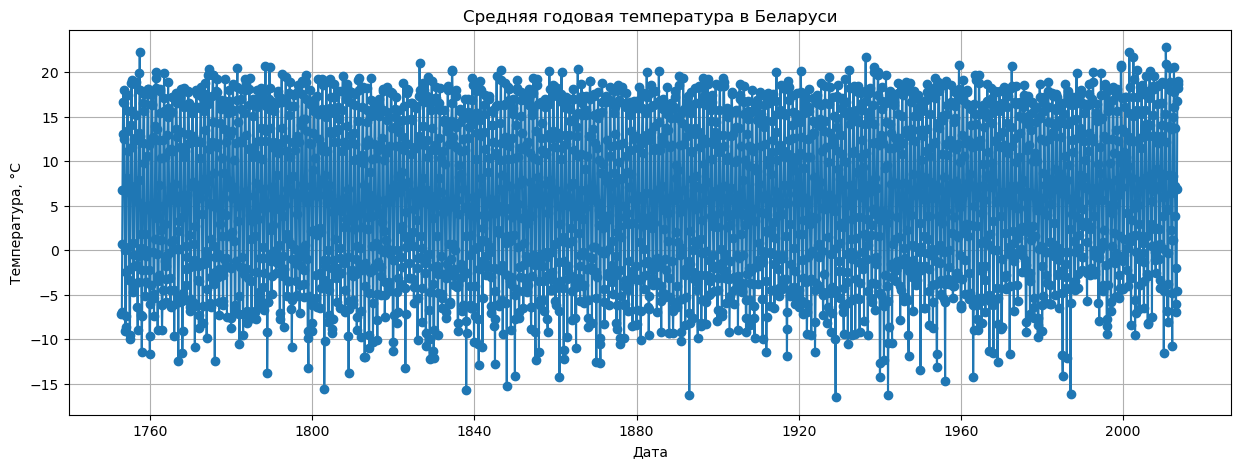

In [21]:
plt.figure(figsize=(15, 5))
plt.plot(belarus_df['AverageTemperature'], marker='o', linestyle='-')
plt.title('Средняя годовая температура в Беларуси')
plt.xlabel('Дата')
plt.ylabel('Температура, °C')
plt.grid(True)
plt.show()

Слишком много данных, картинка не читаемая, используем скользящее среднее для визуализации

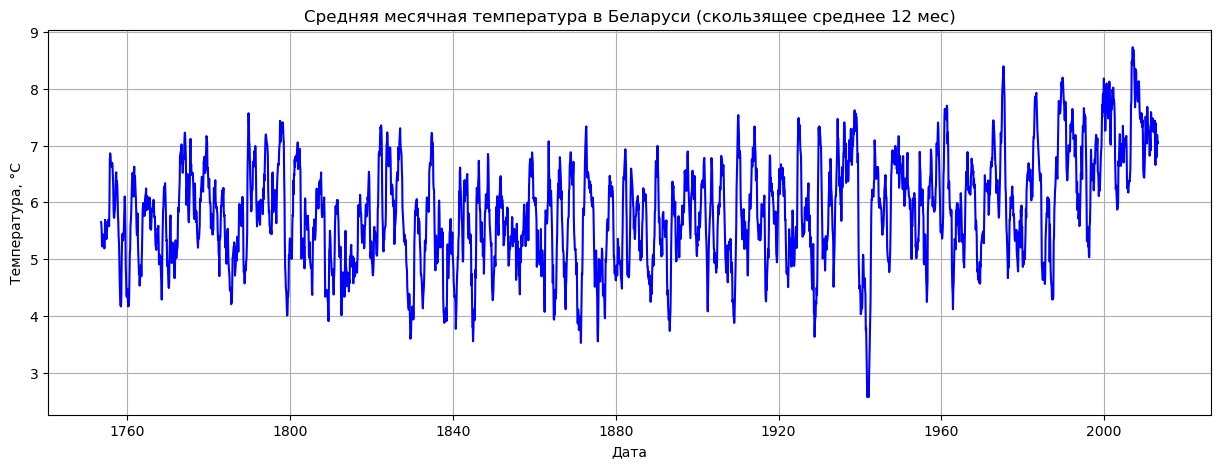

In [23]:
rolling_avg = belarus_df['AverageTemperature'].rolling(window=12, center=True).mean()

plt.figure(figsize=(15, 5))
plt.plot(rolling_avg, color='blue')
plt.title('Средняя месячная температура в Беларуси (скользящее среднее 12 мес)')
plt.xlabel('Дата')
plt.ylabel('Температура, °C')
plt.grid(True)
plt.show()

Визуально видим восходящий тренд и сезонность.

# Holdout-разбиение

Разделим временной ряд: первые 80% наблюдений оставим для обучения, оставшиеся 20% — для теста.

Размер train: 2502, размер test: 626


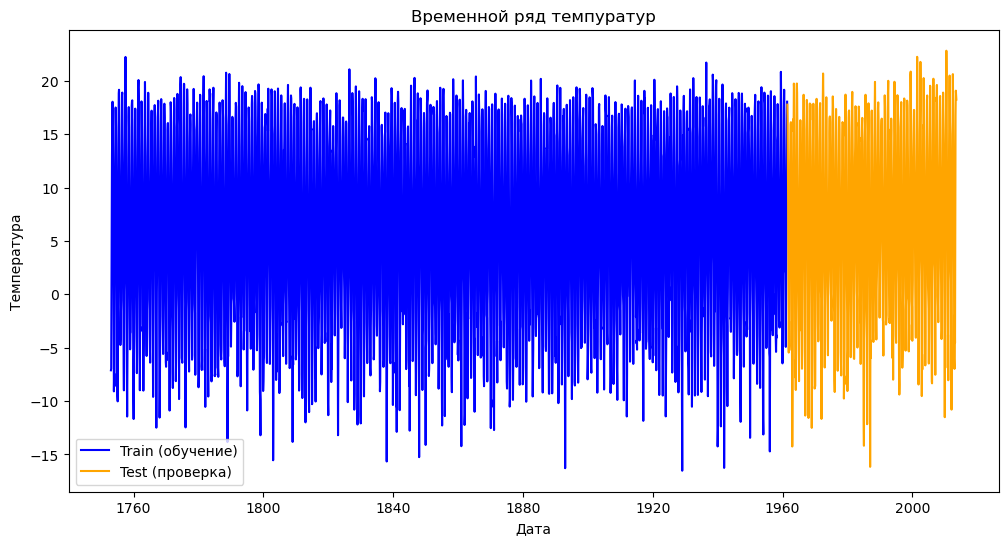

In [27]:
train_size = int(len(belarus_df) * 0.8)
train, test = belarus_df.iloc[:train_size], belarus_df.iloc[train_size:]
 
print(f"Размер train: {len(train)}, размер test: {len(test)}")
 
plt.figure(figsize=(12,6))
 
plt.plot(train.index, train['AverageTemperature'], label='Train (обучение)', color='blue')
plt.plot(test.index, test['AverageTemperature'], label='Test (проверка)', color='orange')

plt.title("Временной ряд темпуратур")
plt.xlabel("Дата")
plt.ylabel("Температура")
plt.legend()
plt.show()

# rolling-window разбиение train

Реализуем rolling-window-разбиение: обучающие отрезки длиной 120 месяцев (10 лет) и прогнозный горизонт 12 месяцев.

In [30]:
train_window = 120
test_window = 12

splits = []
for start in range(0, len(train['AverageTemperature']) - train_window - test_window + 1, test_window):
    train_start = start
    train_end = start + train_window
    test_end = train_end + test_window

    train_idx = train['AverageTemperature'].index[train_start:train_end]
    test_idx = train['AverageTemperature'].index[train_end:test_end]

    splits.append((train_idx, test_idx))

Визуализируем первые два сплита

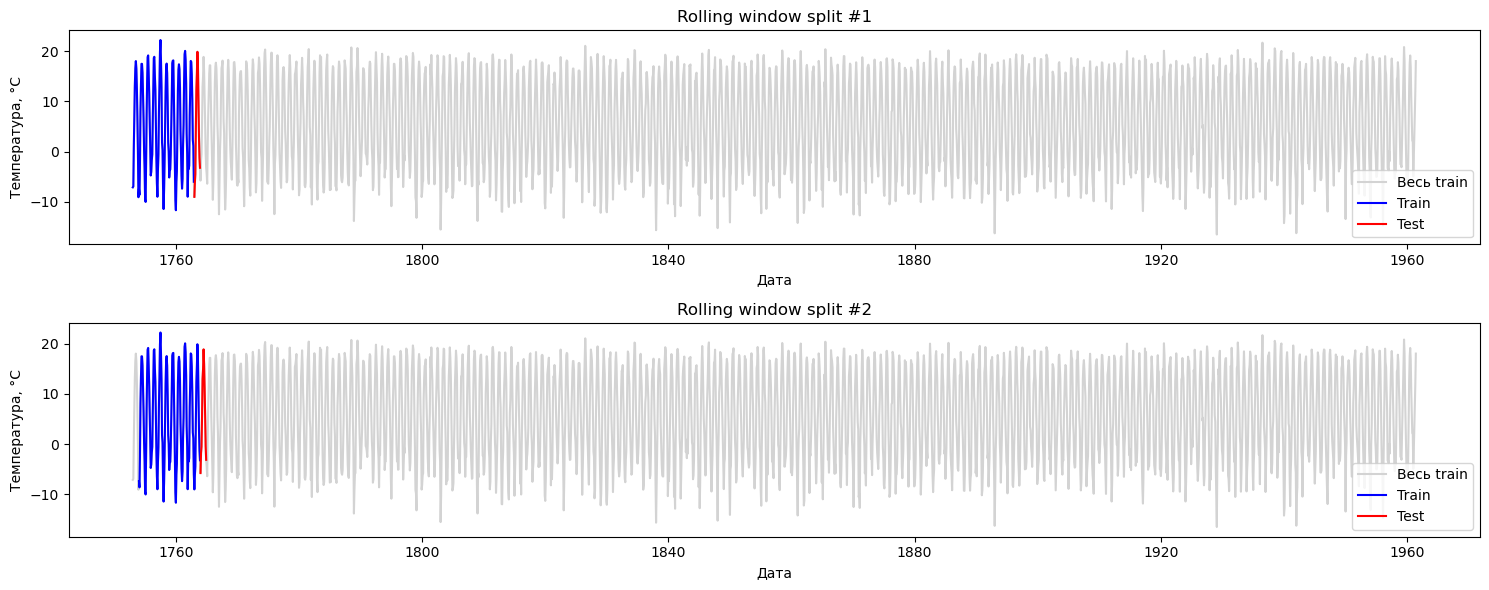

In [32]:
plt.figure(figsize=(15, 6))

for i, (train_idx, test_idx) in enumerate(splits[:2], 1):
    plt.subplot(2, 1, i)
    plt.plot(train['AverageTemperature'], color='lightgray', label='Весь train')
    plt.plot(train_idx, train['AverageTemperature'].loc[train_idx], color='blue', label='Train')
    plt.plot(test_idx, train['AverageTemperature'].loc[test_idx], color='red', label='Test')
    plt.title(f'Rolling window split #{i}')
    plt.xlabel('Дата')
    plt.ylabel('Температура, °C')
    plt.legend()

plt.tight_layout()
plt.show()

# Генерация признаков

In [34]:
belarus_df['lag_1'] = belarus_df['AverageTemperature'].shift(1)    # лаг на 1 месяц
belarus_df['lag_12'] = belarus_df['AverageTemperature'].shift(12)  # лаг на 12 месяцев

belarus_df['month'] = belarus_df.index.month  # номер месяца (1-12)

belarus_df['is_winter'] = belarus_df['month'].isin([12, 1, 2]).astype(int)

belarus_df.head(15)

,AverageTemperature,lag_1,lag_12,month,is_winter
dt,,,,,
1753-01-01,-7.122,NaN,NaN,1,1
1753-02-01,-6.956,-7.122,NaN,2,1
1753-03-01,0.706,-6.956,NaN,3,0
1753-04-01,6.768,0.706,NaN,4,0
1753-05-01,13.060,6.768,NaN,5,0
1753-06-01,16.615,13.060,NaN,6,0
1753-07-01,18.032,16.615,NaN,7,0
1753-08-01,16.501,18.032,NaN,8,0
1753-09-01,12.448,16.501,NaN,9,0


# Оценка прогноза

In [36]:
# Удалим строки с NaN (из-за лагов)
df_model = belarus_df.dropna()

# заново сделаем Holdout-разбиение поскольку были добавлены новые признаки
train_size = int(len(df_model) * 0.8)
train, test = df_model.iloc[:train_size], df_model.iloc[train_size:]

X_train = train.drop(columns=['AverageTemperature'])
y_train = train['AverageTemperature']
X_test = test.drop(columns=['AverageTemperature'])
y_test = test['AverageTemperature']

In [37]:
model = LinearRegression()
model.fit(X_train, y_train);

In [38]:
y_pred = model.predict(X_test)

In [39]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")

MAE:  2.037
RMSE: 7.360
MAPE: 229.77%


Высокий MAPE — это не ошибка модели, а особенность метрики для данных, где возможны нули и отрицательные значения.

MAE 2 градуса, что неплохо для среднемесячной температуры. Больший RMSE указывает, что модель иногда сильно промахивается, визуализируем прогноз, чтобы увидеть это.

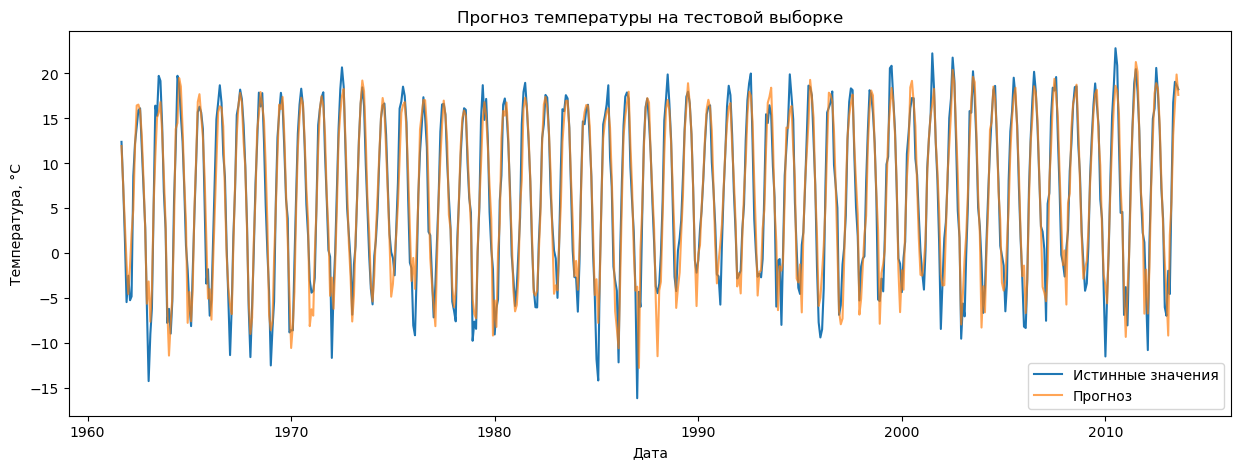

In [41]:
plt.figure(figsize=(15,5))
plt.plot(y_test.index, y_test, label='Истинные значения')
plt.plot(y_test.index, y_pred, label='Прогноз', alpha=0.7)
plt.legend()
plt.title('Прогноз температуры на тестовой выборке')
plt.xlabel('Дата')
plt.ylabel('Температура, °C')
plt.show()

Визуально прогноз корректный, но плохо предсказывает пики температур.